# Excitation via Intrinsic Mode Function (IMF) Synthesis

This method builds excitation series by **additively combining** oscillatory modes
inspired by Intrinsic Mode Functions from Hilbert–Huang / EMD-style analysis
(via [`PySDKit`](https://github.com/wwhenxuan/PySDKit) for AM / sawtooth backends).

Compared with mixed-distribution noise (highly random) or ARMA (smooth temporal
dependence), IMF synthesis emphasizes **multi-scale periodicity** and
**non-stationary amplitude / frequency** structure.

## Principle

A classical IMF has the AM–FM form

$$
u_k(t) = A_k(t)\,\cos\bigl(\phi_k(t)\bigr),
\qquad
A_k(t)\ge 0,\quad
\phi_k'(t)\ge 0,
$$

with envelope and instantaneous frequency varying more slowly than the carrier.

We synthesize a channel as

$$
y(t)
=
\sum_{k}\, w_k\, u_k(t)
+\sum_{j}\, b_j(t)
+\tau(t)
+\varepsilon(t),
$$

then rescale mean-square energy to a random target $\le$ `upper_energy`.

| Symbol | Role in this generator |
| --- | --- |
| $u_k$ | Base tones / chirps and choice IMFs (sin, cos, AM, sawtooth) |
| $A_k(t)$ | Optional **localized envelope** (Gaussian / sech / Tukey / asymmetric; may be inverted) |
| $\phi_k(t)$ | Constant tone or **linear chirp** $\phi(t)=2\pi(f_0 t+\tfrac12\beta t^2)+\phi_0$ on $t\in[0,1]$ |
| $b_j$ | Extra **wavelet-like bursts** (always enveloped) |
| $\tau$ | Optional **trend** (linear / piecewise / nonlinear) on components or the sum |
| $\varepsilon$ | Gaussian noise with $\mathrm{STD}=\texttt{noise\_level}\cdot\mathrm{RMS}(y)$ |
| $w_k$ | Amplitudes with optional **freq→amp decay** (quieter high-frequency modes) |

Default knobs favour diversity: `envelope_prob=0.40`, `trend_prob=0.35`,
`chirp_prob=0.25`, `amplitude_decay_with_freq=True`, `max_wavelets=3`.

In [1]:
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../.."))
warnings.filterwarnings("ignore")

from s2generator.excitation import IntrinsicModeFunction
from s2generator.excitation.intrinsic_mode_functions import (
    _make_envelope,
    _chirp_carrier,
    _tone_carrier,
    _unit_time,
)

plt.rcParams.update(
    {"figure.figsize": (12, 3.5), "axes.grid": True, "grid.alpha": 0.3, "font.size": 11}
)
SEQ_LEN = 512
print("IntrinsicModeFunction ready")

IntrinsicModeFunction ready


## Helpers: time / spectrum plots

In [2]:
def onesided_psd(x):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    return np.fft.rfftfreq(len(x)), np.abs(np.fft.rfft(x)) ** 2


def plot_series_grid(series_list, titles, ncols=2, xlim=None, sharey=False):
    n = len(series_list)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(6 * ncols, 2.6 * nrows), sharey=sharey
    )
    axes = np.atleast_1d(axes).ravel()
    for ax, y, title in zip(axes, series_list, titles):
        ax.plot(y, lw=1.0)
        ax.set_title(title, fontsize=11)
        if xlim is not None:
            ax.set_xlim(*xlim)
    for ax in axes[n:]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()


def plot_time_spectrum(y, title=""):
    y = np.asarray(y).ravel()
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
    axes[0].plot(y, lw=1.1)
    axes[0].set_title("Time domain")
    freqs, psd = onesided_psd(y)
    axes[1].semilogy(freqs, psd + 1e-12, lw=1.1)
    axes[1].set_title("Power spectrum")
    axes[1].set_xlabel("cycles / sample")
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


def make_imf(**kwargs):
    return IntrinsicModeFunction(**kwargs)


def sample(imf, seed=0, seq_len=SEQ_LEN, channels=1):
    return imf.generate(
        np.random.RandomState(seed), seq_length=seq_len, num_channels=channels
    )

## 1. Building blocks: envelopes and chirps

Envelopes peak at a controllable **center** (not only at the ends). Chirps sweep frequency over the unit interval.

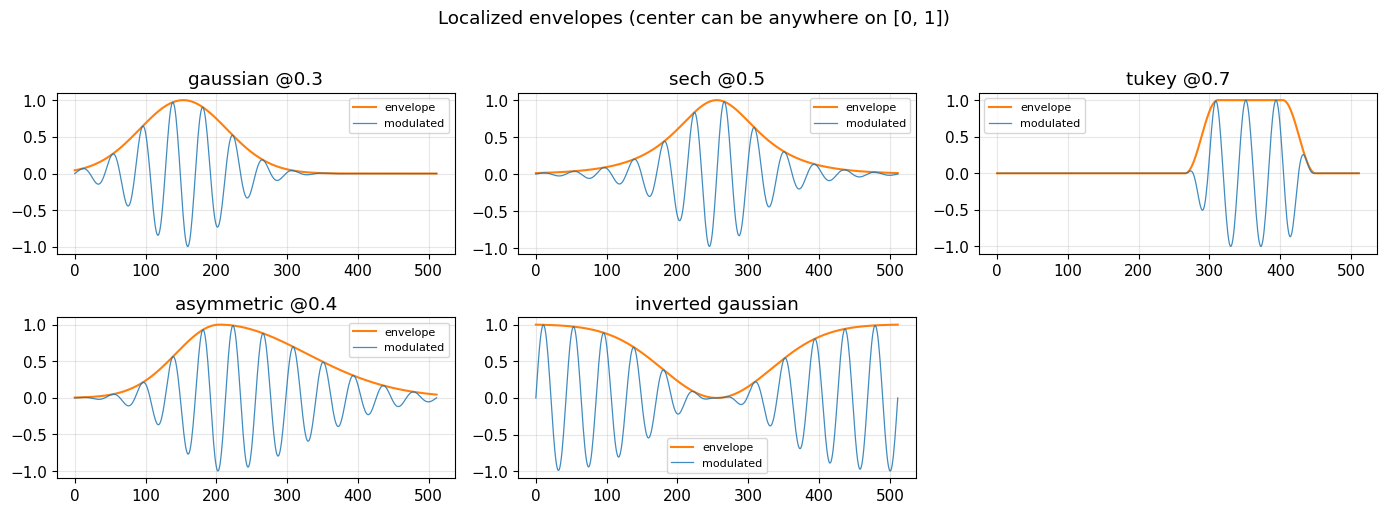

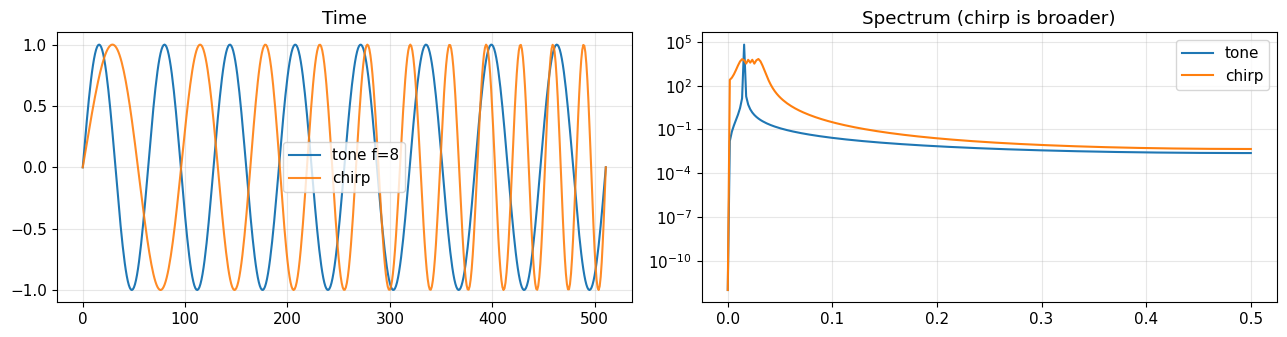

In [3]:
t = _unit_time(SEQ_LEN)
carrier = _tone_carrier(t, frequency=12.0)

envs = {
    "gaussian @0.3": _make_envelope(t, 0.3, 0.12, "gaussian"),
    "sech @0.5": _make_envelope(t, 0.5, 0.10, "sech"),
    "tukey @0.7": _make_envelope(t, 0.7, 0.18, "tukey"),
    "asymmetric @0.4": _make_envelope(t, 0.4, 0.12, "asymmetric", asymmetry=2.0),
    "inverted gaussian": _make_envelope(t, 0.5, 0.15, "gaussian", inverted=True),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 5))
for ax, (name, env) in zip(axes.ravel(), envs.items()):
    ax.plot(env, label="envelope", color="C1", lw=1.5)
    ax.plot(carrier * env, label="modulated", alpha=0.85, lw=0.9)
    ax.set_title(name)
    ax.legend(fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("Localized envelopes (center can be anywhere on [0, 1])", y=1.02)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(_tone_carrier(t, 8.0), label="tone f=8")
axes[0].plot(_chirp_carrier(t, f0=4.0, beta=14.0), label="chirp", alpha=0.9)
axes[0].legend()
axes[0].set_title("Time")
f1, p1 = onesided_psd(_tone_carrier(t, 8.0))
f2, p2 = onesided_psd(_chirp_carrier(t, 4.0, 14.0))
axes[1].semilogy(f1, p1 + 1e-12, label="tone")
axes[1].semilogy(f2, p2 + 1e-12, label="chirp")
axes[1].legend()
axes[1].set_title("Spectrum (chirp is broader)")
fig.tight_layout()
plt.show()

## 2. Default generator: rich random samples

With defaults enabled, each draw mixes envelopes, trends, chirps, and bursts.

IntrinsicModeFunction
envelope_prob=0.4, trend_prob=0.35, chirp_prob=0.25, max_wavelets=3


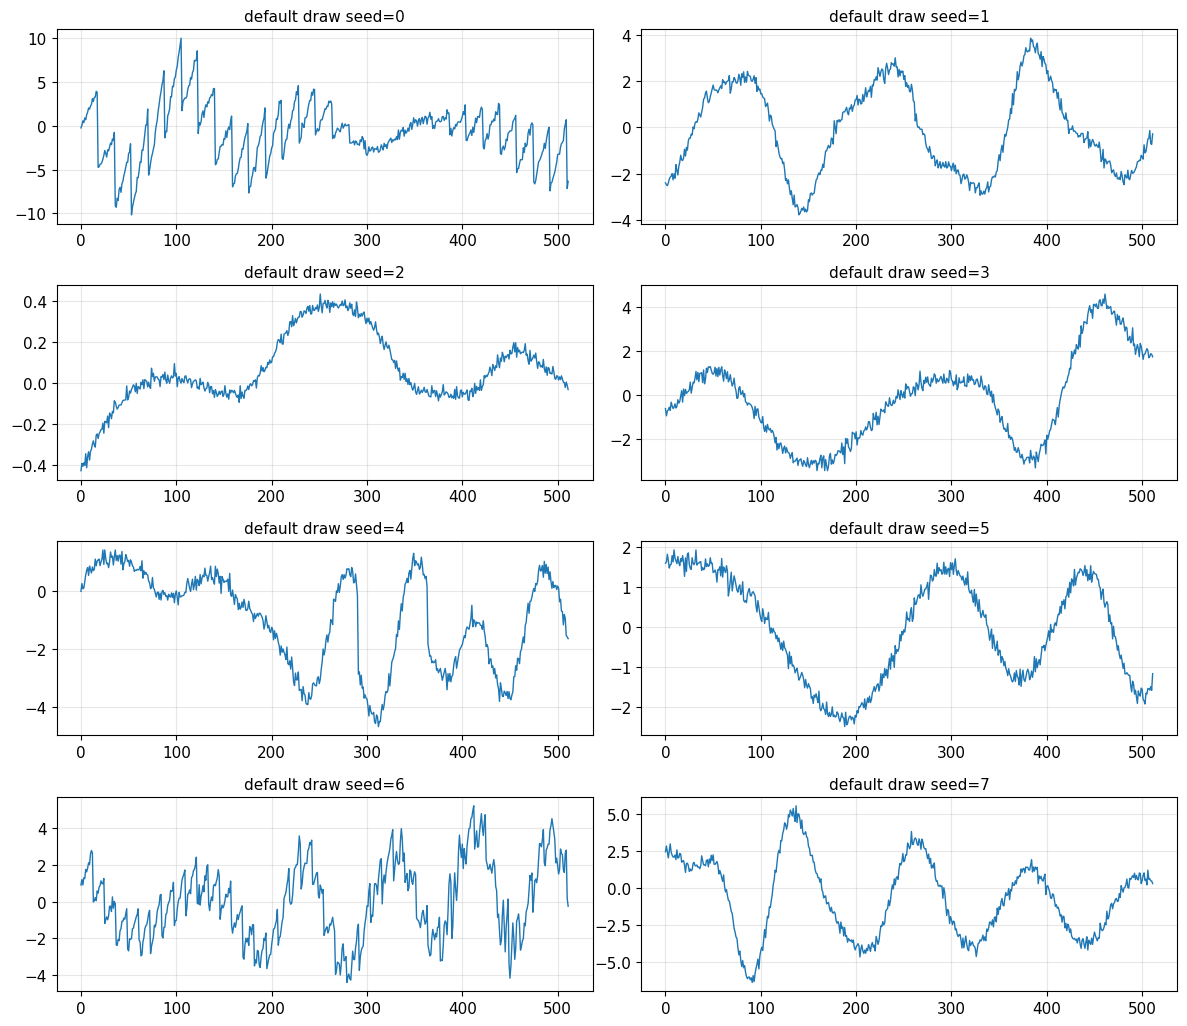

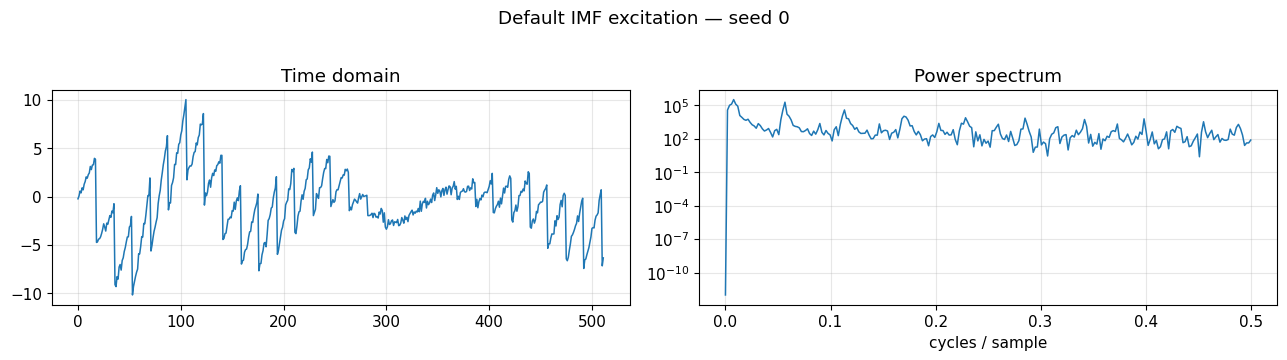

In [4]:
imf_default = make_imf()
print(imf_default)
print(
    f"envelope_prob={imf_default.envelope_prob}, trend_prob={imf_default.trend_prob}, "
    f"chirp_prob={imf_default.chirp_prob}, max_wavelets={imf_default.max_wavelets}"
)

samples = [sample(imf_default, seed=s)[:, 0] for s in range(8)]
plot_series_grid(
    samples,
    [f"default draw seed={s}" for s in range(8)],
    ncols=2,
)
plot_time_spectrum(samples[0], title="Default IMF excitation — seed 0")

## 3. Ablation gallery

Fix the seed and toggle feature groups to see what each mechanism contributes.

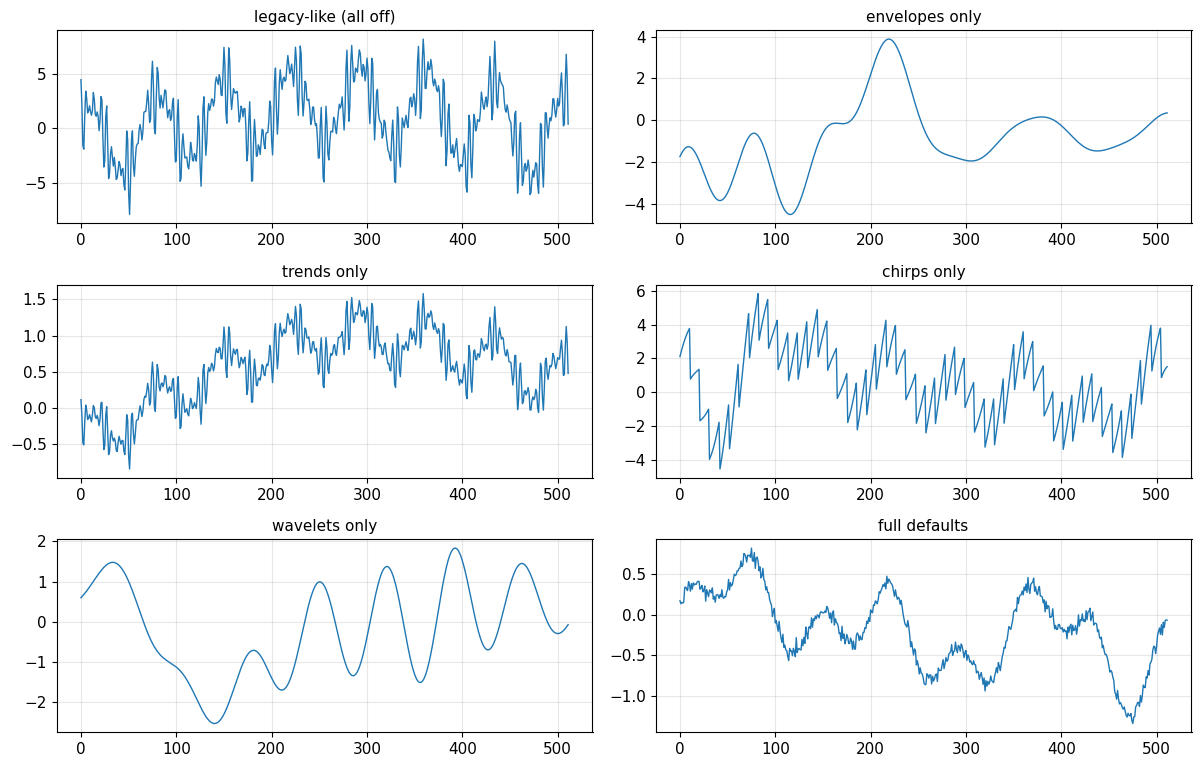

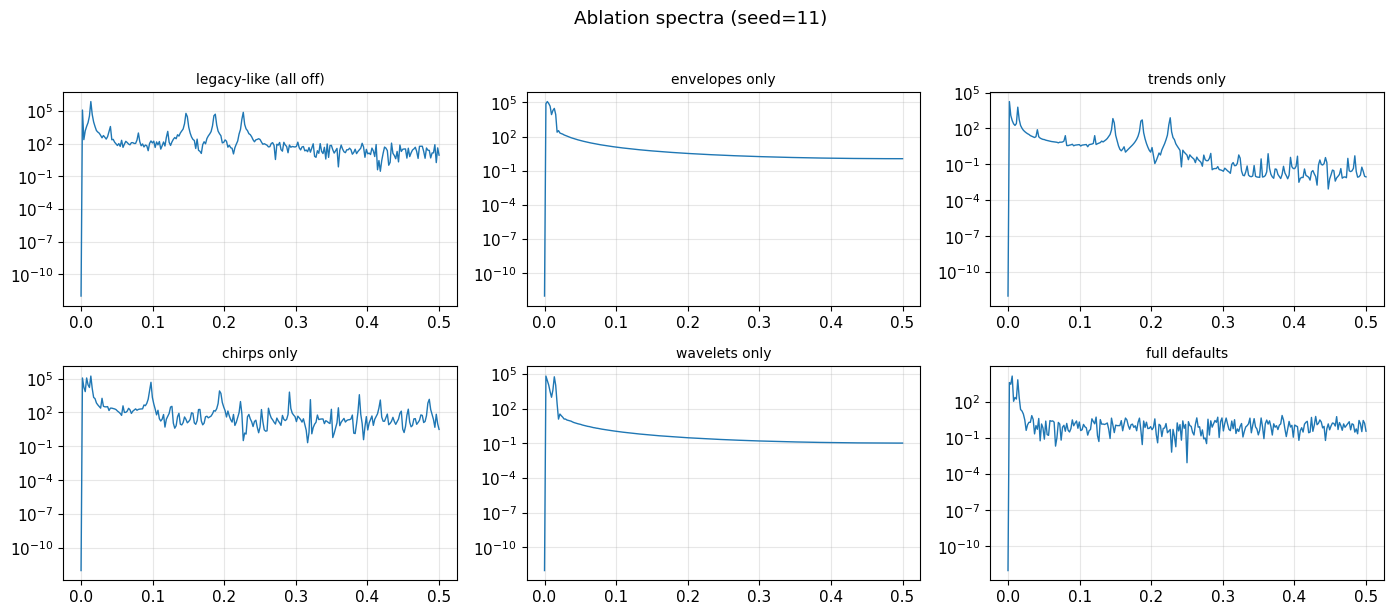

In [5]:
SEED = 11
ablations = {
    "legacy-like (all off)": dict(
        envelope_prob=0.0,
        trend_prob=0.0,
        chirp_prob=0.0,
        min_wavelets=0,
        max_wavelets=0,
        amplitude_decay_with_freq=False,
        noise_level=0.05,
    ),
    "envelopes only": dict(
        envelope_prob=1.0,
        trend_prob=0.0,
        chirp_prob=0.0,
        min_wavelets=0,
        max_wavelets=0,
        noise_level=0.0,
    ),
    "trends only": dict(
        envelope_prob=0.0,
        trend_prob=1.0,
        trend_apply_on="sum",
        chirp_prob=0.0,
        min_wavelets=0,
        max_wavelets=0,
        noise_level=0.0,
    ),
    "chirps only": dict(
        envelope_prob=0.0,
        trend_prob=0.0,
        chirp_prob=1.0,
        min_wavelets=0,
        max_wavelets=0,
        noise_level=0.0,
    ),
    "wavelets only": dict(
        min_base_imfs=0,
        max_base_imfs=0,
        min_choice_imfs=0,
        max_choice_imfs=0,
        min_wavelets=3,
        max_wavelets=3,
        envelope_prob=0.0,
        trend_prob=0.0,
        chirp_prob=0.0,
        noise_level=0.0,
        upper_energy=None,
    ),
    "full defaults": dict(),
}

abl_series, abl_titles = [], []
for name, kw in ablations.items():
    y = sample(make_imf(**kw), seed=SEED)[:, 0]
    abl_series.append(y)
    abl_titles.append(name)

plot_series_grid(abl_series, abl_titles, ncols=2)

# Spectra for a subset
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, y, title in zip(axes.ravel(), abl_series, abl_titles):
    f, p = onesided_psd(y)
    ax.semilogy(f, p + 1e-12, lw=1.0)
    ax.set_title(title, fontsize=10)
fig.suptitle(f"Ablation spectra (seed={SEED})", y=1.02)
fig.tight_layout()
plt.show()

## 4. Multi-channel draws and energy hierarchy

Channels are independent. With `amplitude_decay_with_freq=True`, high-frequency
carriers tend to receive smaller amplitudes.

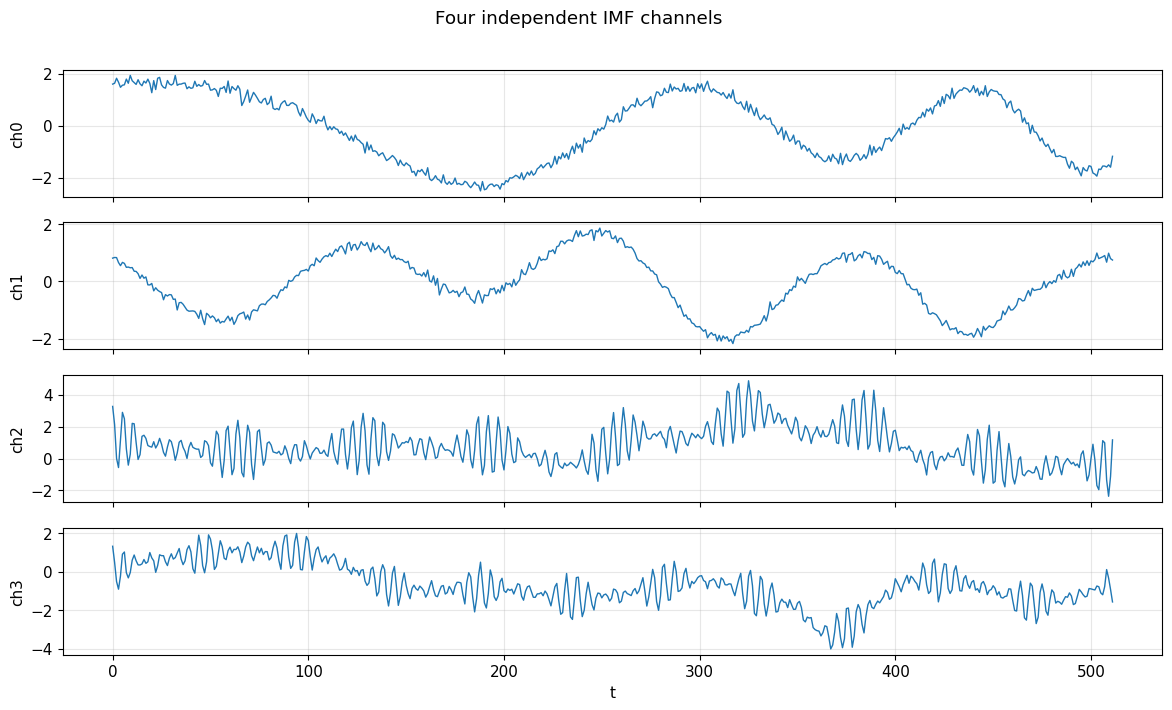

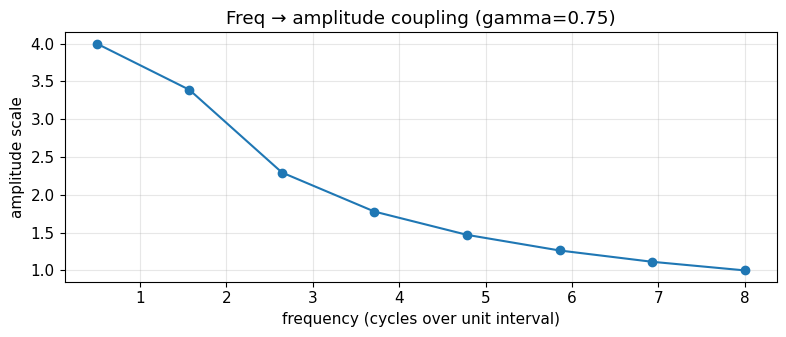

In [6]:
Y = sample(make_imf(), seed=5, channels=4)
fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for c, ax in enumerate(axes):
    ax.plot(Y[:, c], lw=1.0)
    ax.set_ylabel(f"ch{c}")
axes[-1].set_xlabel("t")
fig.suptitle("Four independent IMF channels", y=1.01)
fig.tight_layout()
plt.show()

imf = make_imf(amplitude_decay_with_freq=True, amplitude_decay_gamma=0.75)
freqs = np.linspace(0.5, 8.0, 8)
amps = [imf._scale_amplitude_for_frequency(1.0, f) for f in freqs]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(freqs, amps, "o-")
ax.set_xlabel("frequency (cycles over unit interval)")
ax.set_ylabel("amplitude scale")
ax.set_title("Freq → amplitude coupling (gamma=0.75)")
fig.tight_layout()
plt.show()

## 5. Parameter map (quick reference)

| Group | Parameters |
| --- | --- |
| Counts | `min/max_base_imfs`, `min/max_choice_imfs`, `min/max_wavelets` |
| Carrier stats | `min/max_amplitude`, `min/max_frequency`, `chirp_prob`, `chirp_rate_range` |
| Envelopes | `envelope_prob`, `envelope_families`, `envelope_center_range`, `envelope_width_range`, `envelope_invert_prob` |
| Trends | `trend_prob`, `trend_kinds`, `trend_strength_range`, `trend_apply_on`, `max_trend_segments` |
| Hierarchy / noise | `amplitude_decay_with_freq`, `amplitude_decay_gamma`, `noise_level`, `upper_energy` |
| Choice mix | `probability_dict` / `probability_list` over PySDKit IMF names |

### Tuning tips

- More **local transients**: raise `envelope_prob`, `max_wavelets`, tighten `envelope_width_range`.
- More **non-stationary drift**: raise `trend_prob`, use `trend_apply_on="sum"` for global slope.
- More **FM diversity**: raise `chirp_prob` / widen `chirp_rate_range`.
- Closer to classical steady sinusoid stacks: set envelope/trend/chirp probs to `0` and `max_wavelets=0`.

```python
from s2generator.excitation import IntrinsicModeFunction
import numpy as np

imf = IntrinsicModeFunction()  # rich defaults
y = imf.generate(np.random.RandomState(0), seq_length=512, num_channels=1)
```